# ERA5 vs the ARM observations at Utqiaġvik

Recreates the season phase-hour stack for the single ERA5 grid cell holding the
DOE ARM facility, then collapses it to the two categories Genie's observational
figure uses — **liquid containing** (red) and **ice only** (blue) — so the two
can be read side by side.

## What is and is not comparable

**The coloured hours are.** Both figures count hours per season in which a
liquid-containing or ice-only cloud was overhead at Utqiaġvik.

**Her precipitating categories are not separated here.** Genie splits
precipitating cases into lighter shades. This analysis applies no precipitation
filter, so:

| ERA5 category | corresponds to, in her figure |
|---|---|
| liquid containing | red **+** pink (`with liquid` + `with liquid (precip)`) |
| ice only | blue **+** light blue (`ice only` + `ice only (precip)`) |

**Bar heights are not.** Her bars run to the full season because she stacks
clear sky and a hatched *missing / no data* category on top. These bars stop at
the overcast total. Pass `include_clear=True` to add a grey remainder and match
her layout — the annotation still reports the overcast hours either way.

**ERA5 has no missing data.** A season short of hours is scaled up to the
nominal window rather than shown as a gap, so there is no counterpart to her
hatched bars. `--min-season-coverage` guards against that scaling being applied
to a badly incomplete season.

**Sampling differs.** ERA5 is a 0.25° grid-box average sampled hourly; the ARM
instruments see a point, far faster. Occupancy fractions compare; event
durations do not.

## Setup

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import warnings
from pathlib import Path

import matplotlib.pyplot as plt

import plot_lwp_histogram_by_surface_class as lwph

# open_mfdataset warns about join/compat defaults changing; the module pins
# both explicitly, so the warning is noise here.
warnings.filterwarnings("ignore", category=FutureWarning)

plt.rcParams["figure.dpi"] = 110      # on-screen only; saved files use --dpi

# Set to a directory to write PNGs as well as display them; None displays only.
# SAVE_DIR = None
SAVE_DIR = Path("figures/genie_comparison")

## Load the data

Set the season window and years to match the observational record you are
comparing against. Genie's figure runs 2015–2025.

In [2]:
A = lwph.prepare(
    region="barrow",
    years=tuple(range(2014, 2025)),   # season START years, matching Genie's span
    season_start=(10, 1),
    season_end=(3, 31),

    phase_mode="fraction",
    liquid_fraction_min=0.90,         # LWP/CWP at or above this = liquid only
    ice_fraction_min=0.850,            # IWP/CWP at or above this = ice only

    min_lwp=0.01,                     # g m-2, liquid below this counts as absent
    min_iwp=0.01,                     # g m-2, ice below this counts as absent

    min_cloud_fraction=0.95,          # overcast only
    lsm_tol=0.01,
    storage="local",
)

Liquid-bearing cloud hours by LWP and surface class
  Source     : /Users/andrewbuggee/Documents/VS_CODE/Python-Research/ERA5/surface_energy_budget/data/barrow
  Grid       : 41 x 61 cells, 108,120 time steps
  Season     : 10-01 to 03-31  (wraps the new year)
  Classes    : lsm tol 0.01 | open ocean < 0.05 | pack ice > 0.95
  Cloudy     : tcc >= 0.95
  Phase mode : fraction
  Categories : liquid only: LWP/CWP >= 0.9 | ice only: IWP/CWP >= 0.85 | mixed: the rest | CWP = LWP + IWP above 0.01/0.01 g m-2
               ice only: IWP/CWP >= 0.85
  LWP bins   : linear 0-600 in 24 | log 0.01-1000 in 12

  Seasons found (18), coverage of the 182-183-day window:
    1999/2000:  49.7%   (below --min-season-coverage)
    2000/2001: 100.0%  (common year)
    2001/2002:  50.5%  (common year)   (below --min-season-coverage)
    2011/2012: 100.0%
    2012/2013: 100.0%  (common year)
    2013/2014: 100.0%  (common year)
    2014/2015: 100.0%  (common year)
    2015/2016: 100.0%
    2016/2017: 100.0% 

## 1. Three categories — liquid only, mixed phase, ice only

The figure from the per-class notebook, for the ARM cell alone. One grid cell,
so no averaging over cells is involved.

  -> figures/genie_comparison/barrow_season_phase_stack_site_mean2014-2024.png


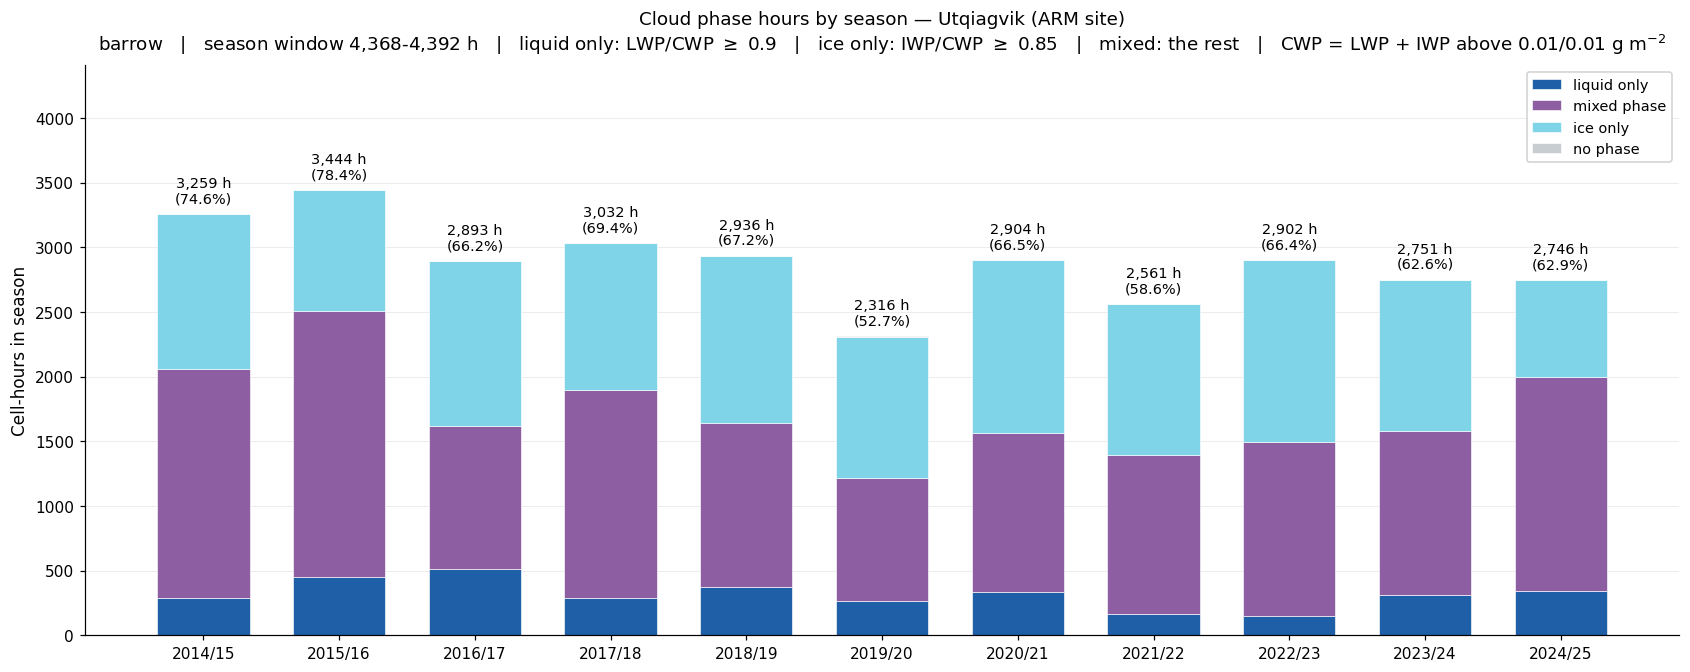

In [3]:
lwph.fig_season_phase_stack_site(A, out_dir=SAVE_DIR);

## 2. Two categories — liquid containing vs ice only

Liquid only and mixed phase are merged into **liquid containing**: both are
scenes an instrument would report as having liquid somewhere in the column. The
small *no phase* residual is folded into ice-only rather than dropped, so the
two still sum to the overcast total — it is overcast time carrying no cloud
water above the minimum paths, which nothing would call liquid.

Colours match Genie's figure exactly.

  -> figures/genie_comparison/barrow_season_phase_binary_site_mean2014-2024.png


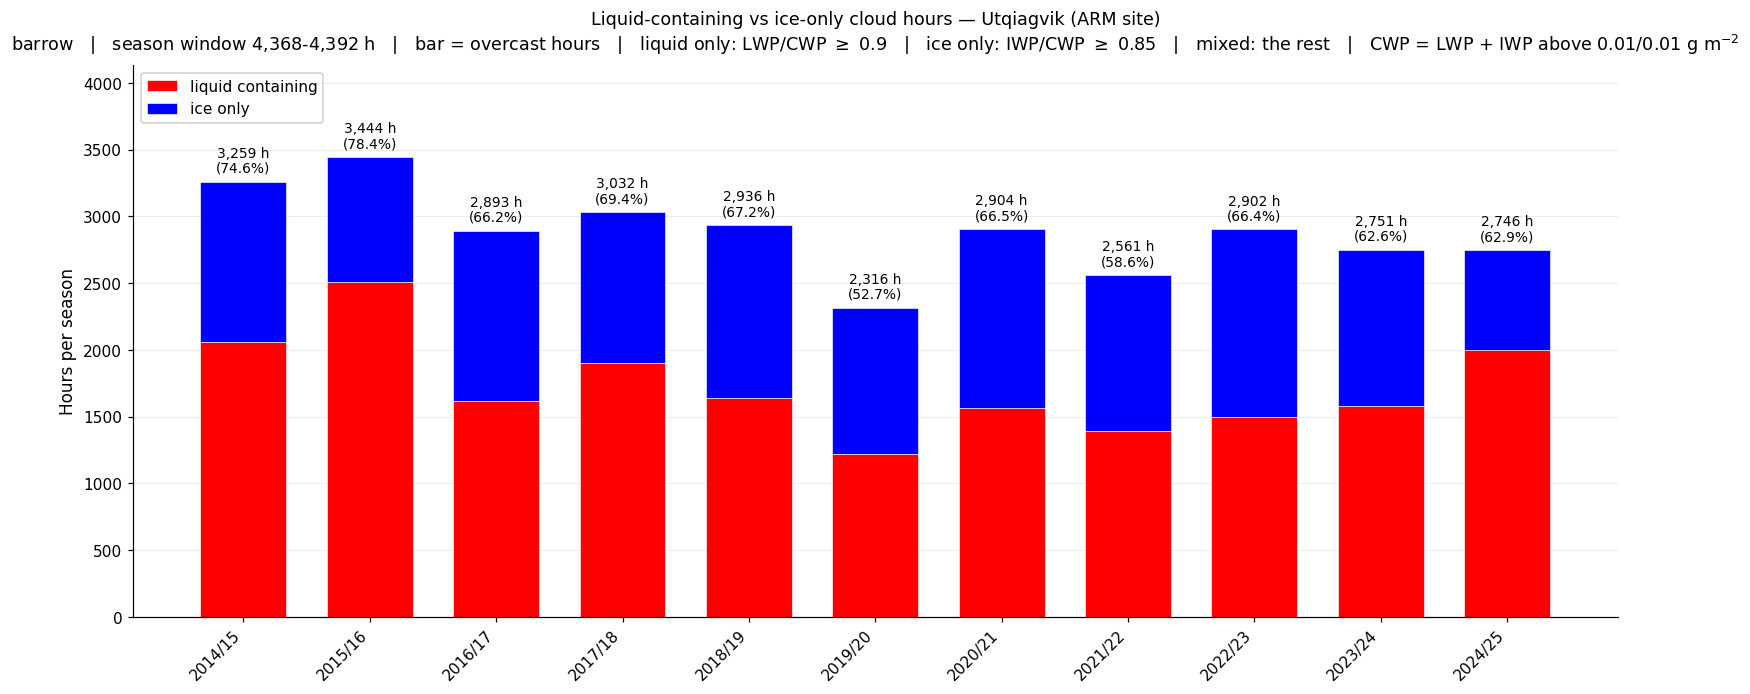

In [4]:
lwph.fig_season_phase_binary(A, out_dir=SAVE_DIR);

### The same, with clear sky stacked on top

Matches her layout, where each bar spans the whole season. The annotation still
gives the overcast hours, not the bar height.

  -> figures/genie_comparison/barrow_season_phase_binary_site_mean2014-2024.png


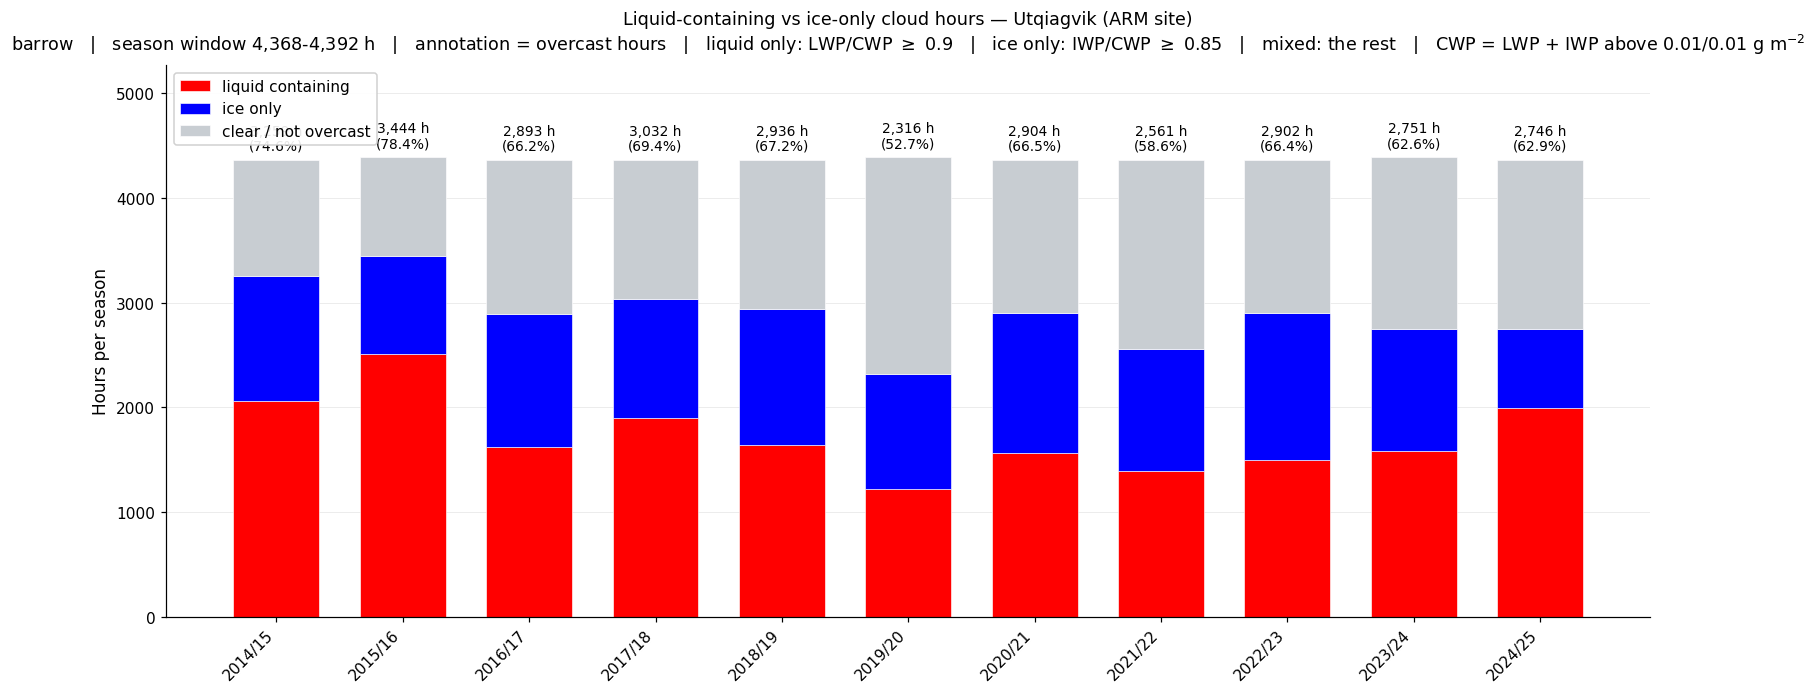

In [5]:
lwph.fig_season_phase_binary(A, include_clear=True, out_dir=SAVE_DIR);

## 3. The numbers, against hers

Her figure's legend gives the record means. The comparison to make is ERA5's
liquid-containing against her red **+** pink, and ERA5's ice-only against her
blue **+** light blue.

In [6]:
import numpy as np

labels, liquid, ice, clear, season_h = lwph.season_phase_binary(A)
code_i, series_label = lwph.resolve_series_code(A.col, "arm_site")
liq, ic = liquid[:, code_i], ice[:, code_i]

# season_h is per season now: a common-year Oct-Mar window is 182 days,
# a leap-year one 183, so there is no single window length to print.
print(f"{series_label} | season window {lwph.window_label(season_h)}\n")
print(f"  {'season':<10}{'liquid-cont':>13}{'ice only':>11}{'cloudy':>10}"
      f"{'% season':>10}{'liq share':>11}")
for i, lab in enumerate(labels):
    tot = liq[i] + ic[i]
    print(f"  {lab:<10}{liq[i]:>13,.0f}{ic[i]:>11,.0f}{tot:>10,.0f}"
          f"{100 * tot / season_h[i]:>9.1f}%{100 * liq[i] / tot:>10.1f}%")

print(f"\n  ERA5 mean        liquid-containing {liq.mean():>7,.0f} h"
      f"   ice-only {ic.mean():>7,.0f} h"
      f"   liquid share {100 * liq.mean() / (liq.mean() + ic.mean()):.1f}%")

# Genie's own numbers, straight from the file -- no longer the legend means
# typed in by hand, since the file now holds every season exactly.
o_l_np, o_i_np = lwph.obs_binary(obs_tbl := lwph.load_observations(),
                                 exclude_precip=True)
o_l_all, o_i_all = lwph.obs_binary(obs_tbl, exclude_precip=False)
print(f"  ARM  no precip   liquid-containing {o_l_np.mean():>7,.0f} h"
      f"   ice-only {o_i_np.mean():>7,.0f} h"
      f"   liquid share {100 * o_l_np.mean() / (o_l_np.mean() + o_i_np.mean()):.1f}%")
print(f"  ARM  all sky     liquid-containing {o_l_all.mean():>7,.0f} h"
      f"   ice-only {o_i_all.mean():>7,.0f} h"
      f"   liquid share {100 * o_l_all.mean() / (o_l_all.mean() + o_i_all.mean()):.1f}%")
print(f"  ERA5 - ARM (all sky) {liq.mean() - o_l_all.mean():>+17,.0f} h"
      f"{ic.mean() - o_i_all.mean():>+19,.0f} h")


Utqiagvik (ARM site) | season window 4,368-4,392 h

  season      liquid-cont   ice only    cloudy  % season  liq share
  2014/15           2,059      1,200     3,259     74.6%      63.2%
  2015/16           2,509        935     3,444     78.4%      72.9%
  2016/17           1,619      1,274     2,893     66.2%      56.0%
  2017/18           1,900      1,132     3,032     69.4%      62.7%
  2018/19           1,642      1,294     2,936     67.2%      55.9%
  2019/20           1,218      1,098     2,316     52.7%      52.6%
  2020/21           1,561      1,343     2,904     66.5%      53.8%
  2021/22           1,393      1,168     2,561     58.6%      54.4%
  2022/23           1,496      1,406     2,902     66.4%      51.6%
  2023/24           1,581      1,170     2,751     62.6%      57.5%
  2024/25           1,999        747     2,746     62.9%      72.8%

  ERA5 mean        liquid-containing   1,725 h   ice-only   1,161 h   liquid share 59.8%
  ARM  no precip   liquid-containing   1,4

## 4. The precipitation filter

### Use `tp`, and no download is needed

The published convention for "ERA5 says it is precipitating" is **0.1 mm hr⁻¹**
([Zhang et al. 2024, *J. Climate*](https://journals.ametsoc.org/view/journals/clim/37/5/JCLI-D-23-0302.1.xml)),
chosen to match a rain gauge's minimum measurable amount. That threshold is
defined on a **rate**, and ERA5 carries the rate directly as `tp` — total
precipitation, accumulated over the hour ending at the validity time, in metres
of water equivalent. So `mm hr⁻¹ = tp × 1000`.

**It is already in the archive.** Checked: present in all 654 single-level
files, finite everywhere, covering every season 2014/15–2025/26 at 93–100% of
the Oct–Mar window. It is also already in all three downloader variable sets
(`core`, `recommended`, `extended`), so future downloads keep it. Nothing to
download and nothing to add.

### Why not the column water paths

`tcrw + tcsw` is a suspended **mass path**, not a rate, so using it means
inferring a rate from a burden — which needs a fall speed and a layer depth
neither of which ERA5 gives you. I calibrated that route against `tp` in your
own data and it tops out around 94% agreement:

| | value |
|---|---|
| median rain+snow path where `tp` = 0.08–0.12 mm hr⁻¹ | 48.8 g m⁻² |
| physical `W = R·H/v`, H = 1 km, rain (v = 4 m/s) | 6.9 g m⁻² |
| same, snow (v = 1 m/s) | 27.8 g m⁻² |
| 5th–95th percentile of the path at `tp` ≥ 0.1 mm hr⁻¹ | **21–599 g m⁻²** |

That last row is the point: the burden corresponding to a given rate spans more
than an order of magnitude, so *no* mass-path cut reproduces the rate cut
cleanly. There is no reason to accept that error when the rate itself is on
disk. `precip_var="path"` remains available for comparison, but `"rate"` is now
the default.

### Why it matters for the observations

Genie separates precipitating cases into their own categories, so the filter is
what makes the two sides mean the same thing:

| ERA5 setting | compared against |
|---|---|
| `no_precip=False` | her red **+** pink, blue **+** light blue |
| `no_precip=True` | her red and blue **alone** |

`fig_era5_vs_obs` reads `A.args.no_precip` and picks the matching observation
columns automatically, so the pairing cannot drift out of sync with the run.

Liquid-bearing cloud hours by LWP and surface class
  Source     : /Users/andrewbuggee/Documents/VS_CODE/Python-Research/ERA5/surface_energy_budget/data/barrow
  Grid       : 41 x 61 cells, 108,120 time steps
  Season     : 10-01 to 03-31  (wraps the new year)
  Classes    : lsm tol 0.01 | open ocean < 0.05 | pack ice > 0.95
  Cloudy     : tcc >= 0.95
  Liquid     : cloud liquid water (tclw)
  Phase mode : fraction
  Categories : liquid only: LWP/CWP >= 0.9 | ice only: IWP/CWP >= 0.85 | mixed: the rest | CWP = LWP + IWP above 0.01/0.01 g m-2
               ice only: IWP/CWP >= 0.85
  LWP bins   : linear 0-600 in 24 | log 0.01-1000 in 12

  Seasons found (18), coverage of the 182-183-day window:
    1999/2000:  49.7%   (below --min-season-coverage)
    2000/2001: 100.0%  (common year)
    2001/2002:  50.5%  (common year)   (below --min-season-coverage)
    2011/2012: 100.0%
    2012/2013: 100.0%  (common year)
    2013/2014: 100.0%  (common year)
    2014/2015: 100.0%  (common year)
   

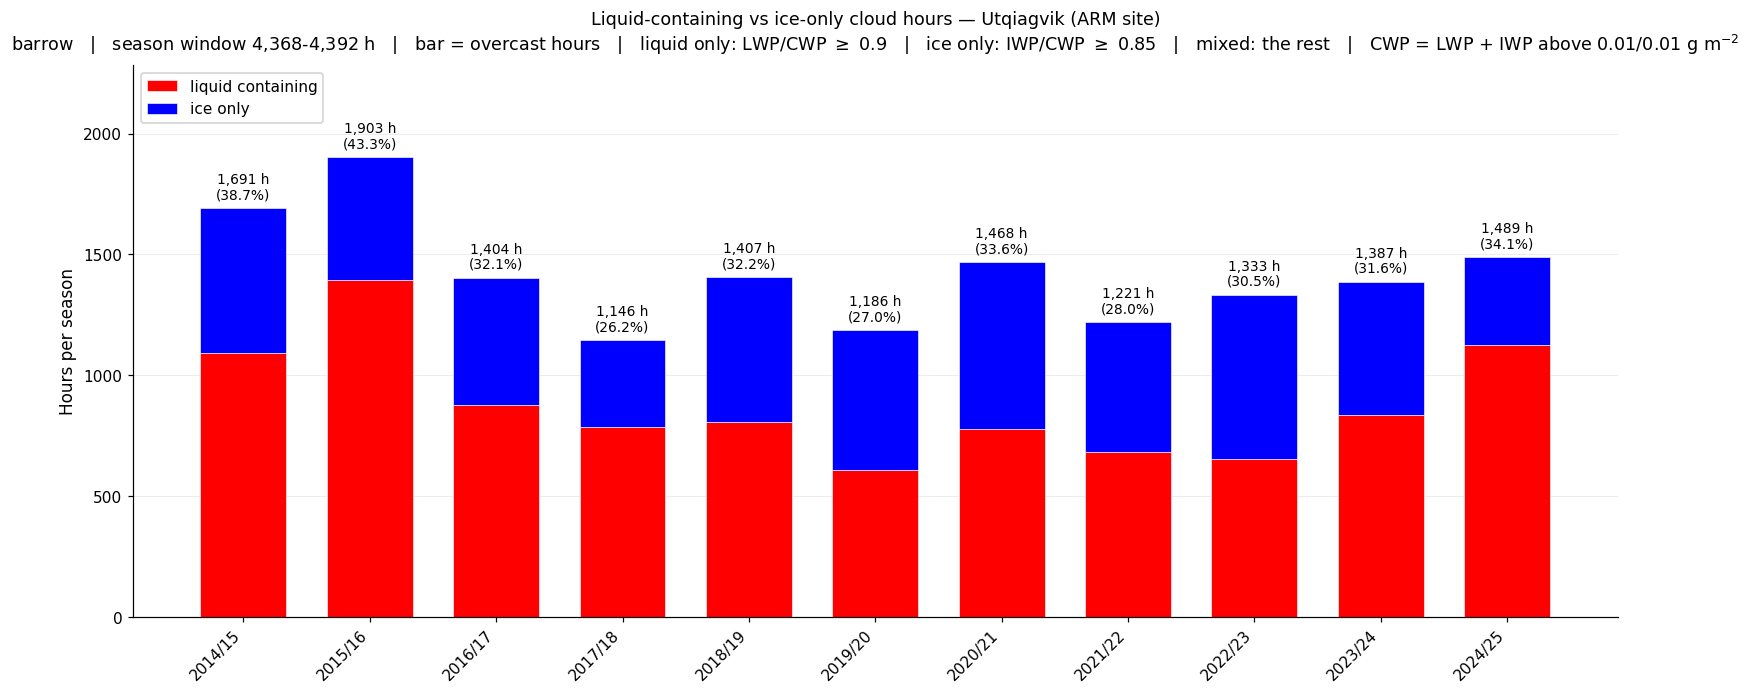

In [35]:
A_precip = lwph.prepare(
    region="barrow",
    years=tuple(range(2014, 2025)),   # season START years, matching Genie's span
    season_start=(10, 1), season_end=(3, 31),
    phase_mode="fraction", liquid_fraction_min=0.90, ice_fraction_min=0.850,
    min_lwp=0.01, min_iwp=0.01, min_cloud_fraction=0.95, lsm_tol=0.01,
    storage="local",

    no_precip=True,             # <- the filter
    precip_var="rate",          # tp, the quantity the 0.1 mm/hr convention uses
    precip_rate_max=0.01,        # mm hr-1
)

removed = A_precip.col["precip_removed"]
before = A_precip.col["cloudy_before_precip"]
print(f"precip filter removed {100 * removed / before:.1f}% of cloudy cell-hours")
lwph.fig_season_phase_binary(A_precip, out_dir=SAVE_DIR);

## 5. ERA5 beside the observations, with residuals

### About the observation file

`genie_arm_seasonal_hours.txt` now holds **Genie's exact numbers**, from
`liquid-containing-clouds-total-hours-per-season.csv`. The values previously in
it were read off her rendered figure by eye; those are gone.

Verified two ways on 2026-09-01: all 66 cells checked against a screenshot of
the Excel sheet (exact), and all six category means reproduce her published
legend to within rounding — with liquid 1474.5 vs 1474, ice only 1071.3 vs
1071, liq precip 282.0 vs 282, ice precip 255.4 vs 255, clear sky 897.7 vs 898,
others 35.8 vs 36.

**There is no digitisation uncertainty left on the seasonal side.**
`OBS_SEASONAL_UNCERTAINTY_H` is 0, so the grey band draws nothing on these two
figures even with `--show-digitization-uncert` set. Residuals here can be read
at face value. The **monthly** file is still digitised and keeps its ±30 h band.

**Season labelling.** The CSV columns are headed `2014/15` … `2024/25`, naming
both years, so there is nothing to infer — unlike her *plot*, whose bars carry
the ending year alone. The file uses the start year to match the ERA5 side, so
the `2014/15` column is stored as 2014. Eleven seasons.

**The `missing` column is derived, not supplied.** The CSV has no missing-data
row, so it is computed as `season window − (the six supplied categories)`, with
a leap-aware window (182 days, or 183 when the ending year is a leap year). It
averages 358 h/season against the 339 h her legend states — a 19 h/season gap
that is *not* explained; a slightly different season window on her side, or
rounding in the cells, are the likely candidates. It only drives the
"incomplete season" asterisk, never a plotted quantity, but don't treat it as
authoritative.

### Two controls shared by sections 5, 6 and 7

**The threshold box.** Each figure now carries a corner box giving
`min cloud fraction` and the liquid-containing cut, so a saved PNG records the
run that made it. Note the direction of the second line: liquid-containing is
liquid-only **plus** mixed-phase, i.e. everything water-bearing that is *not*
ice-only, and ice-only is `IWP/CWP ≥ ice_fraction_min`. The boundary is
therefore

$$\frac{\mathrm{LWP}}{\mathrm{LWP}+\mathrm{IWP}} > 1 - \texttt{ice\_fraction\_min}$$

— **greater than** 10%, not less. `liquid_fraction_min` moves the
liquid-only/mixed boundary only, which this merge cannot see.

**`residual_mode`.** The lower panel takes `residual_mode="percent_diff"`
(the default, $100\,(\text{ERA5}-\text{obs})/\text{obs}$, normalised by the
**observed** value) or `residual_mode="hours"` (the raw difference). It is also
a CLI flag, `--residual-mode`, so `prepare()` can set it once for all three.
Where a band still applies — the monthly figure — it follows the units:
constant in hours, and per-bar in percent, since a fixed ±30 h is a larger
relative error on a small bar. The seasonal figures have no band any more.

observation seasons: 2014/15 .. 2024/25  (11 seasons)
  -> figures/genie_comparison/barrow_era5_vs_obs_noprecip_pct_mean2014-2024.png


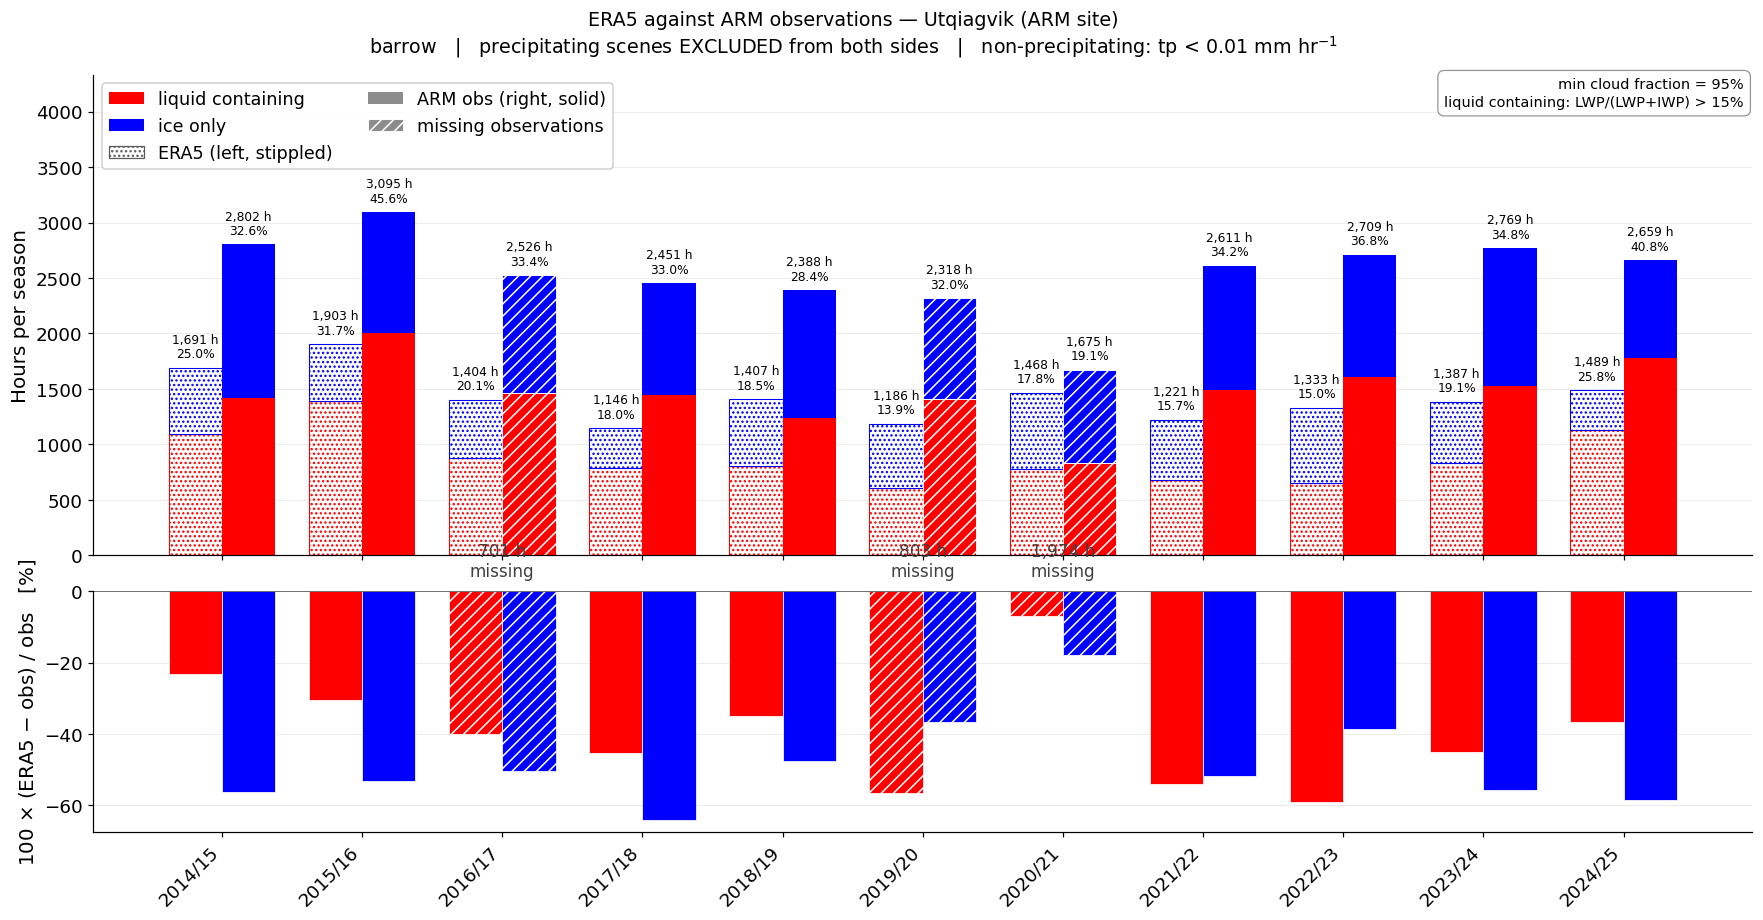

In [36]:
obs = lwph.load_observations()          # validates against the legend means
print(f"observation seasons: {obs['seasons'][0]}/{(obs['seasons'][0]+1)%100:02d}"
      f" .. {obs['seasons'][-1]}/{(obs['seasons'][-1]+1)%100:02d}"
      f"  ({len(obs['seasons'])} seasons)")

# Set USE_PRECIP_FILTER to choose which pairing to plot. The observation
# categories follow automatically.
USE_PRECIP_FILTER = True
A_cmp = A_precip if USE_PRECIP_FILTER else A

lwph.fig_era5_vs_obs(A_cmp, out_dir=SAVE_DIR);

In [20]:
# Same figure, upper panel only -- saved with a " - no-residual-panel" suffix.
# Not displayed here; plt.close() drops it before the cell finishes.
_fig = lwph.fig_era5_vs_obs(A_cmp, out_dir=SAVE_DIR, show_residual=False)
plt.close(_fig)

  -> figures/genie_comparison/barrow_era5_vs_obs_noprecip_pct_mean2014-2024 - no-residual-panel.png


In [22]:
# Season-by-season residual table, same numbers as the lower panel above.
# Seasons with substantially incomplete observations are starred, shown in
# italics, and left out of the Average row. File name carries the two
# threshold settings so a saved table records the run that produced it.
lwph.table_era5_vs_obs_pct_diff(A_cmp, out_dir=SAVE_DIR, font_size=14);

  -> figures/genie_comparison/barrow_era5_vs_obs_noprecip_pct_diff_table_mcf0.95_ifm0.85.png


### Both pairings, side by side

Whether the filter helps is an empirical question, so run it both ways.

In [23]:
import numpy as np

for A_i, tag in ((A, "all-sky"), (A_precip, "precip filtered")):
    labels, liq, ice, _, sh = lwph.season_phase_binary(A_i)
    c, _ = lwph.resolve_series_code(A_i.col, "arm_site")
    o_l, o_i = lwph.obs_binary(obs, exclude_precip=A_i.args.no_precip)
    print(f"\n{tag}:")
    print(f"  ERA5  liquid-containing {liq[:, c].mean():>7,.0f} h"
          f"   ice-only {ice[:, c].mean():>7,.0f} h"
          f"   liquid share {100*liq[:, c].mean()/(liq[:, c].mean()+ice[:, c].mean()):.1f}%")
    print(f"  ARM   liquid-containing {o_l.mean():>7,.0f} h"
          f"   ice-only {o_i.mean():>7,.0f} h"
          f"   liquid share {100*o_l.mean()/(o_l.mean()+o_i.mean()):.1f}%")
    print(f"  diff  {liq[:, c].mean()-o_l.mean():>+22,.0f} h"
          f"{ice[:, c].mean()-o_i.mean():>+20,.0f} h")


all-sky:
  ERA5  liquid-containing   1,725 h   ice-only   1,161 h   liquid share 59.8%
  ARM   liquid-containing   1,756 h   ice-only   1,327 h   liquid share 57.0%
  diff                     -31 h                -166 h

precip filtered:
  ERA5  liquid-containing   1,494 h   ice-only     920 h   liquid share 61.9%
  ARM   liquid-containing   1,474 h   ice-only   1,071 h   liquid share 57.9%
  diff                     +20 h                -151 h


## 6. All sky — nothing filtered, obs precip shown separately

The companion to section 5. There, precipitating scenes are removed from ERA5
and the observations are compared on their non-precipitating categories alone.
Here **nothing is removed from either side**, and the observation bar breaks out
its precipitating categories as their own segments in Genie's shades, so the
part of the comparison the filter would have cut is visible rather than folded
in silently.

ERA5 has no counterpart to that split — the unfiltered run includes
precipitation but does not separate it — so its bar stays two segments. That
asymmetry is the point: it shows how much of the observed cloud time is
precipitating, which is exactly what section 5 removes.

Clear sky is not drawn, as asked. Bars are cloud hours only.

The observation stack is grouped **by phase** rather than in Genie's original
order, so the liquid block and the ice block are each contiguous and can be read
against the two-segment ERA5 bar beside them.

This needs the **unfiltered** `A`; passing `A_precip` raises rather than
silently comparing mismatched populations.

  -> figures/genie_comparison/barrow_era5_vs_obs_allsky_split_pct_mean2014-2024.png


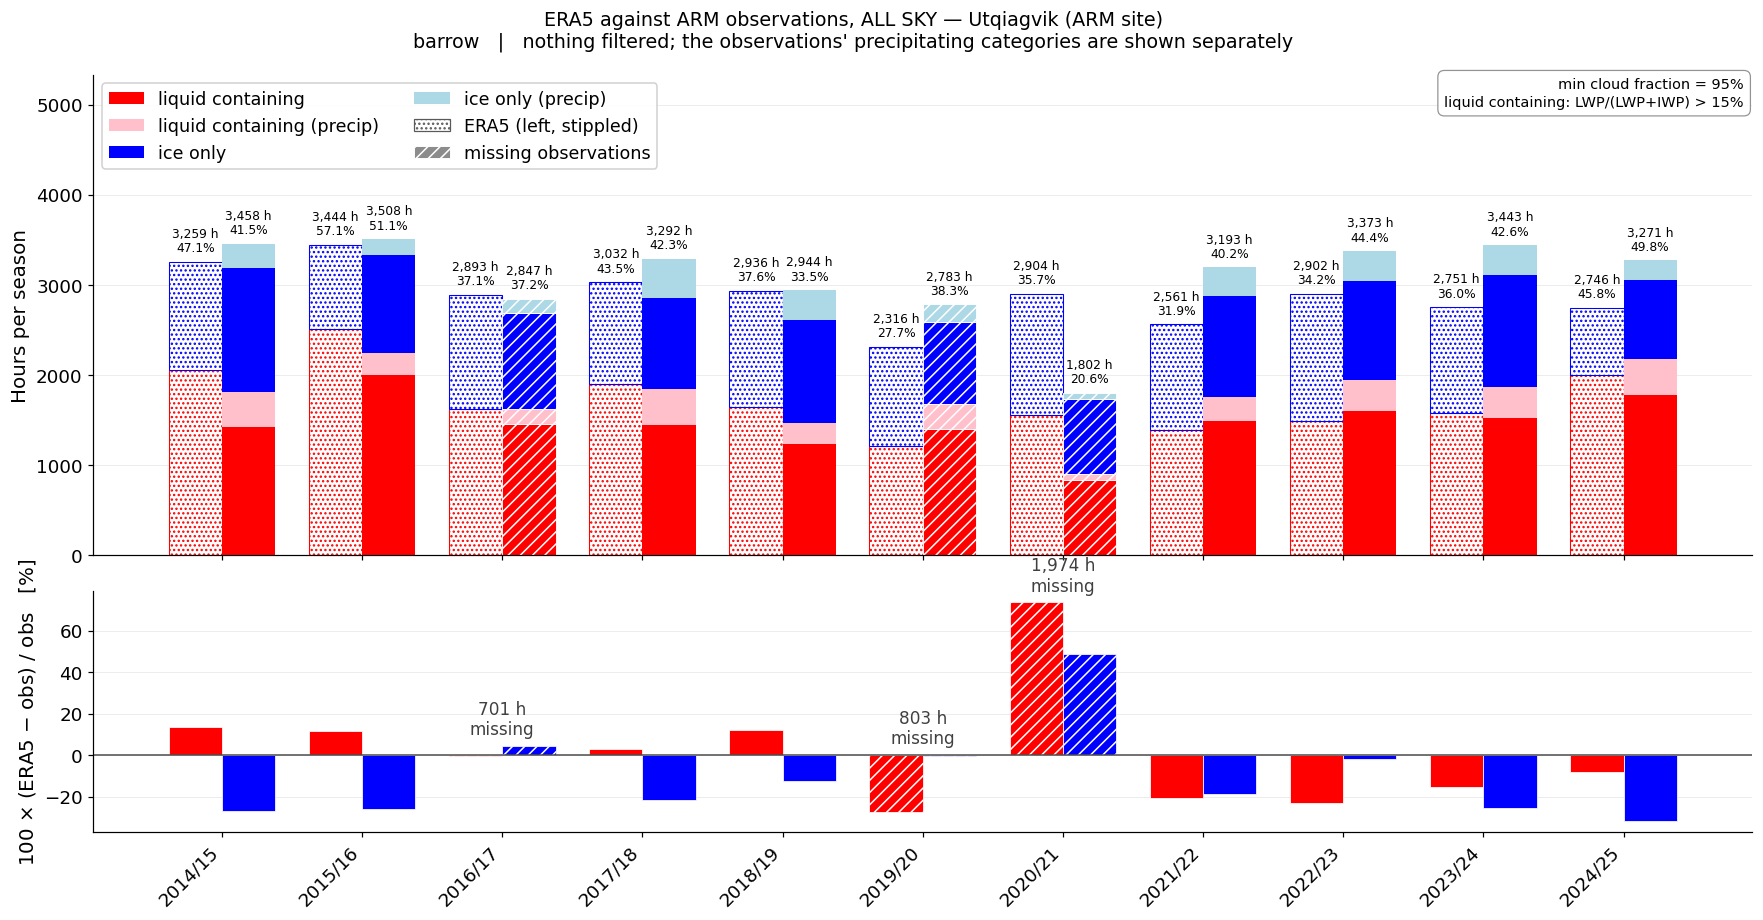

In [24]:
lwph.fig_era5_vs_obs_allsky(A, out_dir=SAVE_DIR);

In [25]:
# Same figure, upper panel only -- saved with a " - no-residual-panel" suffix.
# Not displayed here; plt.close() drops it before the cell finishes.
_fig = lwph.fig_era5_vs_obs_allsky(A, out_dir=SAVE_DIR, show_residual=False)
plt.close(_fig)

  -> figures/genie_comparison/barrow_era5_vs_obs_allsky_split_pct_mean2014-2024 - no-residual-panel.png


In [27]:
# Season-by-season residual table, same numbers as the lower panel above.
lwph.table_era5_vs_obs_allsky_pct_diff(A, out_dir=SAVE_DIR, font_size=14);

  -> figures/genie_comparison/barrow_era5_vs_obs_allsky_split_pct_diff_table_mcf0.95_ifm0.85.png


## 7. Monthly means — ERA5 against the observations

The season axis collapsed: for each calendar month, the mean over seasons of
that month's liquid-containing and ice-only hours, with the observations beside
it. Same layout as sections 5 and 6 — ERA5 stippled on the left, observations
solid on the right, residual underneath.

The whisker on ERA5's liquid segment is **±1 standard deviation across
seasons** — interannual variability, not uncertainty in the mean. There is no
counterpart on the observation side; that file holds means only.

Both sides are **all sky**, since her monthly categories include precipitating
cases. Passing a filtered `A` raises rather than quietly comparing different
populations.

### A cross-check on the monthly file, and what it implies

Summed over the six months, the digitised monthly values give 1,894 h liquid and
1,403 h ice. Her *seasonal* figure's legend states exact means of 1,756 h and
1,326 h — so the monthly totals run 7.9% and 5.8% high.

That is very close to the ratio between the nominal season and its observed
part. The seasonal figure reports 339 h per season as missing, and
4380/(4380−339) = **1.084**, against measured ratios of 1.079 and 1.058.

So the monthly figure looks to be normalised to a **complete** season while the
seasonal figure reports raw hours with the gaps left in. If that reading is
right it makes this the better comparison of the two, because ERA5 has no
missing data and its partial seasons are already scaled to the nominal window
the same way — the two sides would be on a common footing here in a way they are
not in section 5.

**This is an inference from two numbers, not something Genie confirmed.** Worth
asking her before leaning on it.

**This file is still digitised**, unlike the seasonal one, which now holds
Genie's exact numbers. Grouped bars on a common baseline are easier to read off
than stacked segments, so the band is ±30 h — but it is still an estimate, and
the section 5 and 6 residuals are now on a firmer footing than these.
Genie expects to supply the exact monthly values soon.

### Months excluded from both sides

Genie drops several months from her monthly figure: ARM instrument problems
made the retrieved cloud hours anomalously low, so they are an instrumentation
artefact rather than Arctic weather and are not in the means stored in
`genie_arm_monthly_hours.txt`.

ERA5 has no such gaps, so unless the same months are removed from the ERA5 side
the two monthly means are averages over **different samples of seasons**, and
the residual carries that sampling difference on top of any real model bias.
October is the clearest case — two of eleven seasons are missing from the
observed mean and none from ERA5's.

| calendar month | season it falls in |
|---|---|
| Jan 2020 | 2019/20 |
| Oct, Nov, Dec 2020 | 2020/21 |
| Nov 2021 | 2021/22 |
| Feb 2023 | 2022/23 |
| Oct 2023 | 2023/24 |

Seven season-months in total, leaving 9–11 seasons per month instead of 11.
They live in `lwph.GENIE_EXCLUDED_MONTHS` as calendar `(year, month)` pairs;
the season each belongs to is derived from the run's own season window, so
nothing is written down twice. Both `fig_monthly_era5_vs_obs` and
`monthly_phase_binary` apply the list **by default** — pass `exclude_months=()`
to either for the unmasked numbers. Months that lost a season are marked with
a dagger on the x axis and named under the residual panel.

**Scope: section 7 only.** The seasonal figures keep these months, because her
seasonal figure keeps them too and reports the shortfall through its own
*missing hours* category — the one those figures already mark with an asterisk.

If Genie supplies the real CSVs, or revises which months she rejects, that
tuple is the single place to change.

  -> figures/genie_comparison/barrow_monthly_era5_vs_obs_pct_mean2014-2024.png


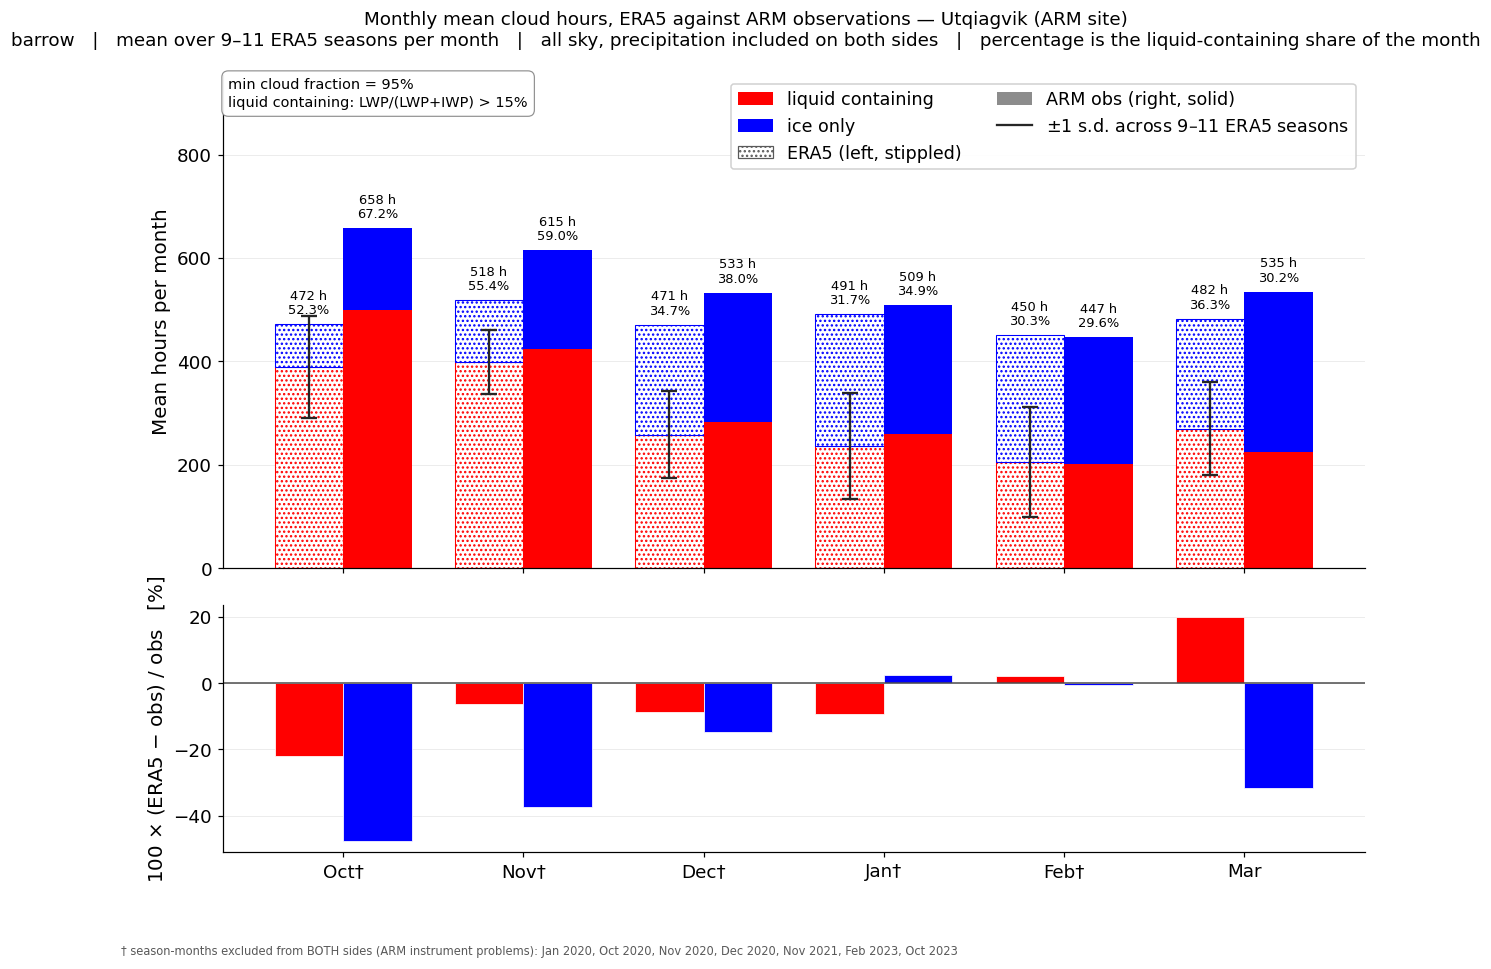

In [28]:
lwph.fig_monthly_era5_vs_obs(A, out_dir=SAVE_DIR);

In [29]:
# Same figure, upper panel only -- saved with a " - no-residual-panel" suffix.
# Not displayed here; plt.close() drops it before the cell finishes.
_fig = lwph.fig_monthly_era5_vs_obs(A, out_dir=SAVE_DIR, show_residual=False)
plt.close(_fig)

  -> figures/genie_comparison/barrow_monthly_era5_vs_obs_pct_mean2014-2024 - no-residual-panel.png


In [30]:
# Month-by-month residual table, same numbers as the lower panel above.
lwph.table_monthly_era5_vs_obs_pct_diff(A, out_dir=SAVE_DIR, font_size=14);

  -> figures/genie_comparison/barrow_monthly_era5_vs_obs_pct_diff_table_mcf0.95_ifm0.85.png


### The numbers behind it

Per month, both sides and the residual.

In [12]:
import calendar
import numpy as np

obs_m = lwph.load_monthly_observations()
months, liq, ice, month_h = lwph.monthly_phase_binary(A)   # exclusions applied
oi = {m: i for i, m in enumerate(obs_m["months"])}

print(f"excluded season-months: "
      f"{', '.join(f'{calendar.month_abbr[m]} {y}' for y, m in lwph.GENIE_EXCLUDED_MONTHS)}\n")
print(f"{'month':<7}{'n':>3}{'ERA5 liq':>10}{'sd':>7}{'obs liq':>9}{'diff':>8}"
      f"{'%':>8}{'ERA5 ice':>11}{'obs ice':>9}{'diff':>8}{'%':>8}{'of':>7}")
for j, m in enumerate(months):
    if m not in oi:
        continue
    n = int(np.isfinite(liq[:, j]).sum())
    el, ei_ = np.nanmean(liq[:, j]), np.nanmean(ice[:, j])
    sd = np.nanstd(liq[:, j])
    ol, oiq = obs_m["with_liquid"][oi[m]], obs_m["ice_only"][oi[m]]
    print(f"{calendar.month_abbr[m]:<7}{n:>3}{el:>10.0f}{sd:>7.0f}{ol:>9.0f}"
          f"{el-ol:>+8.0f}{100*(el-ol)/ol:>+7.1f}%"
          f"{ei_:>11.0f}{oiq:>9.0f}{ei_-oiq:>+8.0f}{100*(ei_-oiq)/oiq:>+7.1f}%"
          f"{month_h[j]:>7.0f}")

# What the exclusion is worth, month by month.
_, liq0, ice0, _ = lwph.monthly_phase_binary(A, exclude_months=())
print(f"\neffect of the exclusion on the ERA5 monthly means [h]:")
print("  " + "  ".join(
    f"{calendar.month_abbr[m]}{np.nanmean(liq[:, j])-np.nanmean(liq0[:, j]):+.0f}"
    f"/{np.nanmean(ice[:, j])-np.nanmean(ice0[:, j]):+.0f}"
    for j, m in enumerate(months)) + "   (liquid/ice)")

excluded season-months: Jan 2020, Oct 2020, Nov 2020, Dec 2020, Nov 2021, Feb 2023, Oct 2023

month    n  ERA5 liq     sd  obs liq    diff       %   ERA5 ice  obs ice    diff       %     of
Oct      9       389     99      500    -111  -22.1%         83      158     -75  -47.6%    744
Nov      9       399     62      425     -26   -6.2%        119      190     -71  -37.3%    720
Dec     10       258     84      283     -25   -8.8%        213      250     -37  -14.7%    744
Jan     10       236    102      260     -24   -9.2%        255      249      +6   +2.5%    744
Feb     10       205    106      201      +4   +2.2%        245      246      -1   -0.4%    679
Mar     11       270     90      225     +45  +20.1%        212      310     -98  -31.6%    744

effect of the exclusion on the ERA5 monthly means [h]:
  Oct+9/-6  Nov+5/-6  Dec+1/-7  Jan+9/+1  Feb+8/-14  Mar+0/+0   (liquid/ice)


## 8. Fitting the two thresholds to the observations

Two knobs decide how many hours ERA5 calls **liquid containing** at the ARM
cell:

| parameter | meaning | range swept |
|---|---|---|
| `min_cloud_fraction` | `tcc ≥ ·` — the overcast gate | 0.90 – 0.99 |
| `ice_fraction_min` | `IWP/(LWP+IWP) ≥ ·` ⇒ ice-only | 0.85 – 0.95 |

A scene is liquid-containing when it is cloudy, holds cloud water above the
minimum paths, and is *not* ice-only — i.e. when its ice share is **below**
`ice_fraction_min`. Note `liquid_fraction_min` is **not** a free parameter: it
moves the liquid-only/mixed boundary, and this merge cannot see it.

Cost is the root-sum-square of the liquid-containing residual, fitted
separately for the three comparisons.

### Why exhaustive grid search, and not an optimiser

Three facts decide this, and they point the same way.

**1. The objective is piecewise constant, so it has no usable gradient.**
Every hour flips category at one discrete threshold. Moving
`min_cloud_fraction` from 0.9500 to 0.9501 changes the answer only if some hour
has `tcc` inside that interval — otherwise the cost is *bit-identical*. The
surface is a staircase: derivative zero almost everywhere, undefined on the
jumps. Gradient descent and L-BFGS have nothing to descend, and a Nelder-Mead
simplex that lands entirely on one tread sees a flat function and collapses.
This rules out the standard optimisers regardless of what an evaluation costs.

**2. Evaluation is essentially free once the archive is read once.** This is
the fact that inverts the usual cost model, and it is the reason not to be
clever. Both parameters are post-hoc scalar tests applied hour by hour, and the
target is **one grid cell** — so a single streaming pass reduces the problem to
a table of ~48,000 rows (season, month, `tcc`, ice share, cloud flag, rain
flag). After that, scoring any pair is two comparisons and a `bincount`: about
a millisecond. A full 91 × 101 grid costs seconds. An optimiser converging in
40 evaluations would save perhaps ten seconds and give up point 3 entirely.

**3. The surface is worth more than the minimum.** Two thresholds that both
remove cloudy hours can trade against each other, and a lone optimum cannot
show that. The full surface separates a sharp, well-identified minimum from a
long diagonal valley in which only *some combination* of the two is
constrained — and it shows whether the minimum sits in the interior or is
pinned to a bound, which is the difference between a fitted value and a bound
the fit wanted to escape.

**Bounding the discretisation error.** Because the cost changes only at values
present in the data, the exact global optimum sits at one of those breakpoints.
A 0.001 grid is finer than either threshold is physically meaningful to, so the
reported optimum is at most one grid step from the exact one — and only inside
a tread where the cost is flat anyway.

### What this is, and is not

**This is calibration, not validation.** Thresholds tuned to reproduce one
observational record cannot then be cited as evidence that ERA5 agrees with it.
The diagnostic use is the honest one: if matching needs a `min_cloud_fraction`
far from 1.0, that says ERA5 needs partly-cloudy scenes counted as overcast to
match a point instrument — a statement about **sampling**, not a tuning knob.

The cost uses the liquid-containing residual alone, as asked, so ice-only is
free to get worse. `report_optimum` prints the ice residual at each optimum as
a check: a fit that repairs liquid while breaking ice has relabelled hours, not
found them.

### Excluded data

Seasons **2016/17, 2019/20, 2020/21 and 2021/22** are dropped from the two
seasonal fits (`fit.EXCLUDED_FIT_SEASONS`). Genie's record is substantially
incomplete in these, and the seasonal file reports the shortfall as raw missing
hours rather than scaling what remains up to a full season — while ERA5 has no
gaps and *is* scaled up. Fitting to them would tune the thresholds to
instrument downtime. The monthly fit uses `GENIE_EXCLUDED_MONTHS` as before.

### 8.1 One pass over the archive

Everything that does not depend on the two free parameters is computed here,
once. The verification is not optional: the fit reimplements the module's
normalisation on a reduced table, so it is only trustworthy if it reproduces
`season_phase_binary` and `monthly_phase_binary` at the run's own thresholds.
`fit.verify` raises if it does not.

In [13]:
import numpy as np

import fit_cloud_thresholds as fit

S_allsky = fit.extract_site_series(A)          # section 6 and 7 population
S_precip = fit.extract_site_series(A_precip)   # section 5 population

print(f"{S_allsky['si'].size:,} hours at ({S_allsky['site_lat']:.3f} N, "
      f"{S_allsky['site_lon']:.3f} E)   |   {S_allsky['n_season']} seasons "
      f"x {S_allsky['n_month']} months")
print(f"seasons dropped from the seasonal fits: "
      f"{', '.join(f'{y}/{(y+1)%100:02d}' for y in fit.EXCLUDED_FIT_SEASONS)}")
print(f"precip threshold on the filtered run: "
      f"{S_precip['precip_rate_max']:g} mm/hr\n")

print("verify, all sky:")
fit.verify(S_allsky, A)
print("verify, precipitation filtered:")
fit.verify(S_precip, A_precip)

48,120 hours at (71.250 N, -156.500 E)   |   11 seasons x 6 months
seasons dropped from the seasonal fits: 2016/17, 2019/20, 2020/21, 2021/22
precip threshold on the filtered run: 0.05 mm/hr

verify, all sky:
  seasonal   max |fit - module| =    0.0000 h (OK)
  monthly    max |fit - module| =    0.0000 h (OK)
verify, precipitation filtered:
  seasonal   max |fit - module| =    0.0000 h (OK)


np.True_

### 8.2 The sweep

91 × 101 = 9,191 threshold pairs per target, evaluated exhaustively. Each
target reports its optimum, how many grid cells tie it exactly (a flat tread
means the two thresholds are not separately identified there), whether the
minimum is pinned to a bound, the improvement over the current setting, and —
for the seasonal targets — what happened to ice-only, which is *not* in the
cost.

In [14]:
import time

obs   = lwph.load_observations()
obs_m = lwph.load_monthly_observations()

SERIES   = {"season_noprecip": S_precip, "season_allsky": S_allsky,
            "monthly_allsky": S_allsky}
ANALYSIS = {"season_noprecip": A_precip, "season_allsky": A,
            "monthly_allsky": A}

surfaces, results = {}, {}
for target in fit.TARGETS:
    t0 = time.time()
    tcc_v, ifm_v, cost = fit.cost_surface(SERIES[target.key], target, obs, obs_m)
    surfaces[target.key] = (tcc_v, ifm_v, cost)
    results[target.key] = fit.report_optimum(
        SERIES[target.key], target, obs, obs_m, tcc_v, ifm_v, cost,
        A=ANALYSIS[target.key])
    lo, hi = float(np.nanmin(cost)), float(np.nanmax(cost))
    print(f"  {tcc_v.size} x {ifm_v.size} = {tcc_v.size * ifm_v.size:,} "
          f"evaluations in {time.time() - t0:.1f} s   |   cost spans "
          f"{lo:,.0f}-{hi:,.0f} h   |   {100 * np.mean(cost <= 1.1 * lo):.1f}% "
          f"of the grid is within 10% of the minimum")


Seasonal, precipitation filtered (section 5)
  fitted   min_cloud_fraction = 0.959   ice_fraction_min = 0.850
  RSS      714.1 h   over 7 seasons   (RMS 269.9 h)
  !! ice fraction pinned to the lower bound -- the fit wanted to leave the allowed range, so this is a bound, not a fitted value
  baseline RSS at (0.950, 0.850) = 737.8 h   -> improvement 3.2%
  ice-only RSS at this optimum = 794.9 h   (was 757.2 h at the baseline)   [not minimised]
  91 x 101 = 9,191 evaluations in 1.0 s   |   cost spans 714-1,565 h   |   24.1% of the grid is within 10% of the minimum

Seasonal, all sky (section 6)
  fitted   min_cloud_fraction = 0.959   ice_fraction_min = 0.870
  RSS      678.4 h   over 7 seasons   (RMS 256.4 h)
  baseline RSS at (0.950, 0.850) = 690.1 h   -> improvement 1.7%
  ice-only RSS at this optimum = 1,018.2 h   (was 848.6 h at the baseline)   [not minimised]
  91 x 101 = 9,191 evaluations in 1.1 s   |   cost spans 678-1,581 h   |   27.8% of the grid is within 10% of the minimum

M

### 8.3 The cost surfaces

Each panel is one target. The star is that target's optimum, the open circle
the current setting. Read the **shape** as much as the star: closed contours
around the star mean the pair is identified; a trough running diagonally means
the two thresholds trade against each other and only their combination is
constrained by these data.

  -> figures/genie_comparison/threshold_fit_cost_surfaces.png

target                                tcc  ice frac     RSS h    RMS h    n
Seasonal, precipitation filtered (section 5)  0.959     0.850       714      270    7
Seasonal, all sky (section 6)       0.959     0.870       678      256    7
Monthly means, all sky (section 7)  0.909     0.850       101       41    6

Seasonal, precipitation filtered (section 5)
        2014     2015     2017     2018     2022     2023     2024
       1,725    2,296    1,548    1,352    1,156    1,238    1,628   ERA5
       1,423    2,004    1,443    1,239    1,606    1,528    1,780   obs
        +302     +292     +105     +113     -450     -290     -152   residual

Seasonal, all sky (section 6)
        2014     2015     2017     2018     2022     2023     2024
       2,063    2,466    1,904    1,656    1,511    1,577    1,978   ERA5
       1,813    2,246    1,849    1,465    1,941    1,869    2,177   obs
        +250     +220      +55     +191 

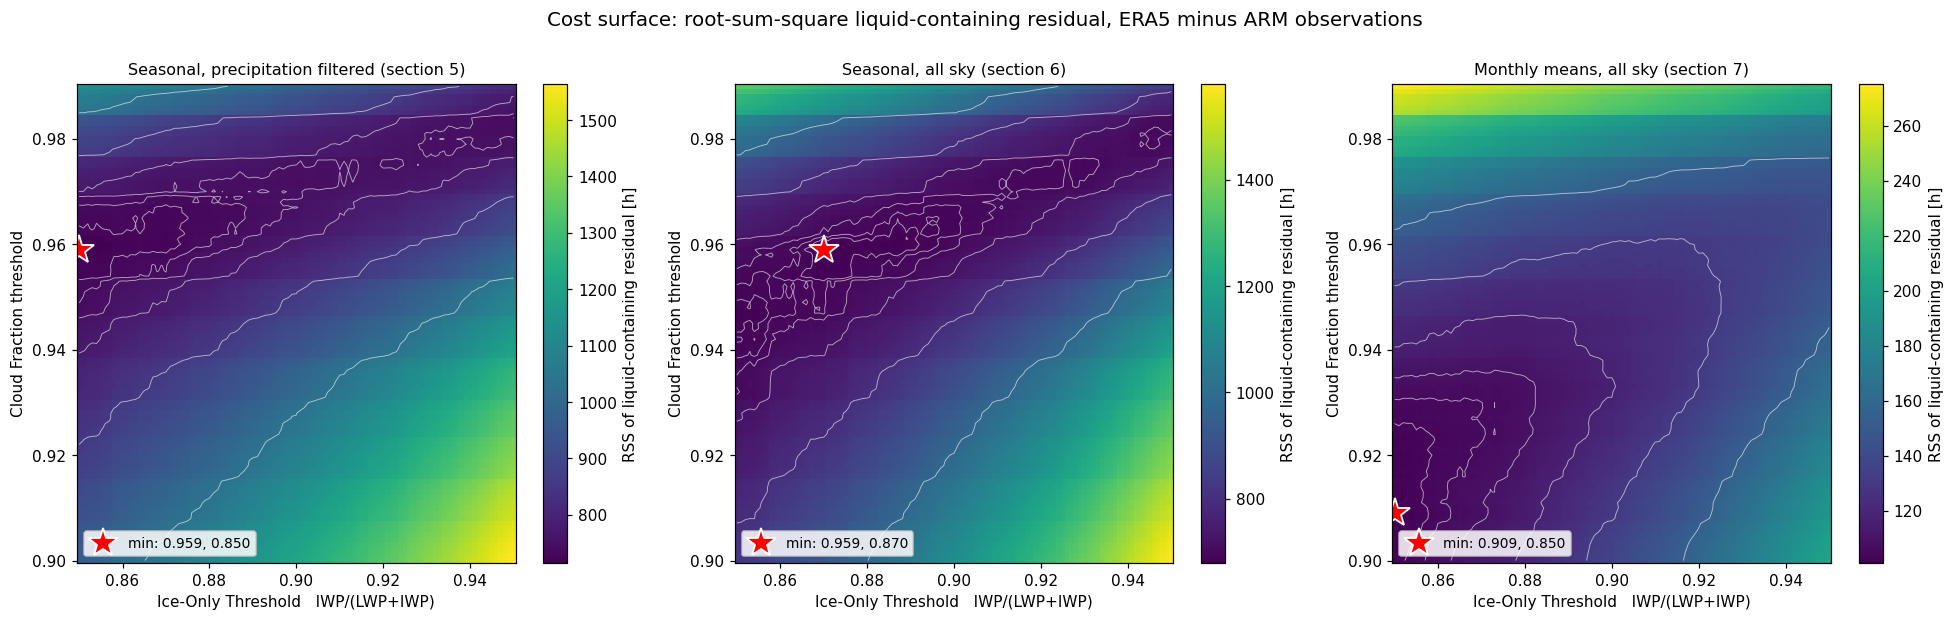

In [34]:
fit.fig_cost_surfaces(S_allsky, results, surfaces, A=A, out_dir=SAVE_DIR)

print(f"\n{'target':<34}{'tcc':>7}{'ice frac':>10}{'RSS h':>10}"
      f"{'RMS h':>9}{'n':>5}")
for target in fit.TARGETS:
    r = results[target.key]
    print(f"{target.label:<34}{r['tcc']:>7.3f}{r['ice_frac']:>10.3f}"
          f"{r['rss']:>10,.0f}{r['rss'] / np.sqrt(len(r['x'])):>9,.0f}"
          f"{len(r['x']):>5}")

# Residuals at each optimum, term by term.
for target in fit.TARGETS:
    r = results[target.key]
    print(f"\n{target.label}")
    print("   " + "".join(f"{str(v):>9}" for v in r["x"]))
    print("   " + "".join(f"{v:>9,.0f}" for v in r["era5"]) + "   ERA5")
    print("   " + "".join(f"{v:>9,.0f}" for v in r["obs"]) + "   obs")
    print("   " + "".join(f"{v:>+9,.0f}" for v in (r["era5"] - r["obs"]))
          + "   residual")

## Reading the comparison

Two questions worth separating when the numbers disagree:

1. **Does ERA5 see cloud as often?** Compare the cloudy totals — ERA5's
   overcast hours against her red + pink + blue + light blue.
2. **Given cloud, does ERA5 get the phase split right?** Compare the liquid
   share, which is insensitive to (1) and is the more physically interesting
   question.

They can fail independently: ERA5 could be too cloudy with the right phase mix,
or correctly cloudy with too little liquid. The `liq share` column above is
built for the second question.

If you want to test sensitivity, `min_lwp` / `min_iwp` and `min_cloud_fraction`
are the levers — each needs a fresh `prepare()`. `liquid_fraction_min` and
`ice_fraction_min` change where the liquid/mixed/ice boundaries fall but not the
liquid-containing vs ice-only split, since that merge is insensitive to the
liquid–mixed boundary.